<a href="https://colab.research.google.com/github/aayushkhanna09/ml-lab/blob/main/ml5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9415204678362573
Confusion Matrix:
 [[ 57   6]
 [  4 104]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



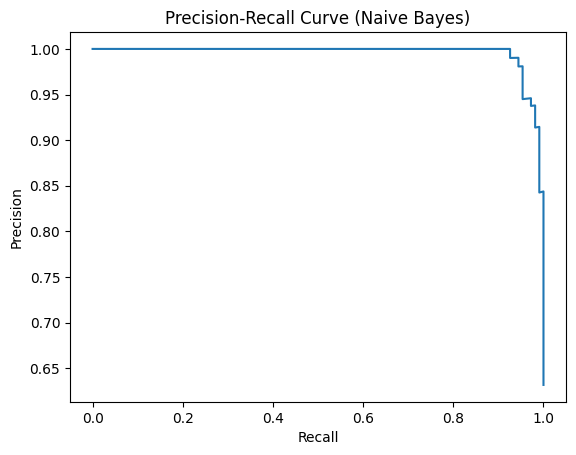

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predictions
y_pred = nb.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Precision Recall Curve
y_prob = nb.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Naive Bayes)")
plt.show()

Accuracy: 0.9415204678362573
Confusion Matrix:
 [[ 60   3]
 [  7 101]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



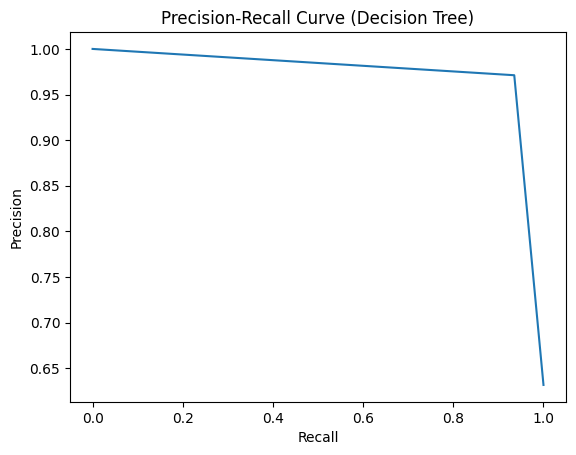

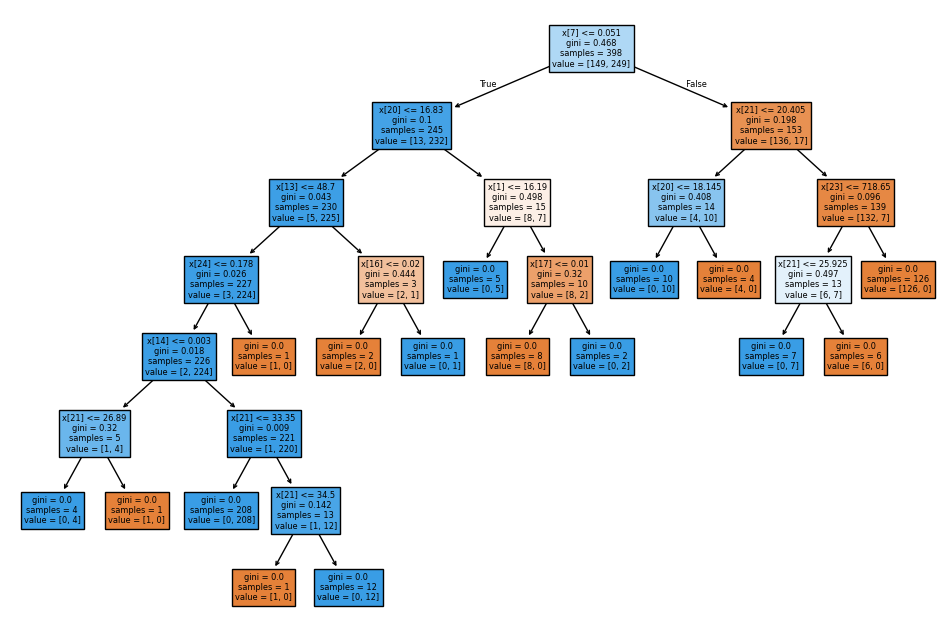

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

# Precision Recall Curve
y_prob_dt = dt.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_dt)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")
plt.show()

# Visualize tree
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True)
plt.show()

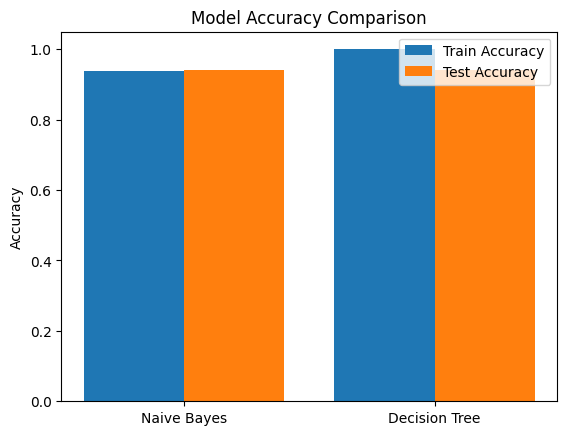

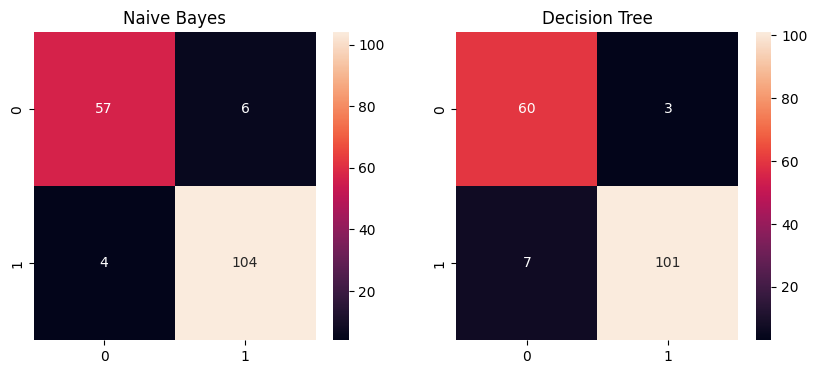

In [ ]:
import seaborn as sns
import numpy as np

# Accuracy comparison
train_acc_nb = nb.score(X_train, y_train)
test_acc_nb = nb.score(X_test, y_test)

train_acc_dt = dt.score(X_train, y_train)
test_acc_dt = dt.score(X_test, y_test)

models = ['Naive Bayes','Decision Tree']
train_scores = [train_acc_nb, train_acc_dt]
test_scores = [test_acc_nb, test_acc_dt]

# Bar Chart
x = np.arange(len(models))
plt.bar(x-0.2, train_scores, 0.4, label="Train Accuracy")
plt.bar(x+0.2, test_scores, 0.4, label="Test Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

# Confusion Matrix Heatmap
cm_nb = confusion_matrix(y_test, y_pred)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_nb, annot=True, fmt="d")
plt.title("Naive Bayes")

plt.subplot(1,2,2)
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree")

plt.show()